# RSNA Bone Age Prediction

## 1. Problem Statement
The objective is to estimate a patient's bone age from hand X-ray images. This is primarily a regression problem (predicting age in months) but also involves classification into developmental stages.

## 2. Methodology
We will use a **ResNet50** Convolutional Neural Network (CNN) pretrained on ImageNet. 
- **Regression**: The final fully connected layer will output a single continuous value (age).
- **Classification**: A separate model head (or separate training run) will classify images into developmental stages.

### Preprocessing
- **Resize**: Images are resized to 256x256 to fit into memory (RTX 3050) and allow for batch processing.
- **Normalization**: Standard ImageNet normalization.
- **Augmentation**: Random rotations, flips, and brightness adjustments to improve generalization.

### Dataset Split
- **Train**: 70%
- **Validation**: 15%
- **Test**: 15%

In [1]:
# Install necessary packages if missing
!pip install tqdm

import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report, cohen_kappa_score
import cv2
import kagglehub
import time
import copy
from tqdm.auto import tqdm
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    # Enable cudnn benchmark for speed
    torch.backends.cudnn.benchmark = True

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Using device: cuda
GPU Name: NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:
def get_data_path():
    # User provided path
    local_path = r"C:\Users\farha\Downloads\archive (4)"
    if os.path.exists(local_path):
        print(f"Using local dataset at: {local_path}")
        return local_path
    
    print(f"Local path {local_path} not found. Attempting download via kagglehub...")
    try:
        path = kagglehub.dataset_download("kmader/rsna-bone-age")
        print(f"Dataset available at: {path}")
        return path
    except Exception as e:
        print(f"Error downloading dataset: {e}")
        return None

data_path = get_data_path()

Using local dataset at: C:\Users\farha\Downloads\archive (4)


In [3]:
# Data Preparation
def prepare_data(root_dir):
    csv_path = os.path.join(root_dir, 'boneage-training-dataset.csv')
    img_dir = os.path.join(root_dir, 'boneage-training-dataset', 'boneage-training-dataset')
    
    # Handle potential directory structure variations
    if not os.path.exists(csv_path):
        csv_files = glob.glob(os.path.join(root_dir, '**', 'boneage-training-dataset.csv'), recursive=True)
        if csv_files:
            csv_path = csv_files[0]
            img_dir = os.path.join(os.path.dirname(csv_path), 'boneage-training-dataset')
        else:
            raise FileNotFoundError("CSV file not found")
            
    df = pd.read_csv(csv_path)
    df['id'] = df['id'].astype(str)
    df['path'] = df['id'].apply(lambda x: os.path.join(img_dir, x + '.png'))
    
    # Filter out missing images
    df = df[df['path'].apply(os.path.exists)].copy() # Use .copy() to avoid SettingWithCopyWarning
    
    # Add Classification Labels (Developmental Stages)
    # 0-24m: Infancy, 25-144m: Childhood, 145-204m: Adolescence, >204m: Young Adult
    bins = [0, 24, 144, 204, 300]
    labels = ['Infant', 'Child', 'Adolescent', 'Young Adult']
    df['stage'] = pd.cut(df['boneage'], bins=bins, labels=labels, right=True)
    df['stage_code'] = df['stage'].cat.codes
    
    return df

if data_path:
    full_df = prepare_data(data_path)
    print(f"Total samples: {len(full_df)}")
    print(full_df.head())
else:
    print("Data path not available. Please check dataset location.")
    # Create a dummy full_df to prevent NameError in later cells if user runs them
    full_df = pd.DataFrame(columns=['id', 'path', 'boneage', 'stage', 'stage_code', 'male'])

Total samples: 12611
     id  boneage   male                                               path  \
0  1377      180  False  C:\Users\farha\Downloads\archive (4)\boneage-t...   
1  1378       12  False  C:\Users\farha\Downloads\archive (4)\boneage-t...   
2  1379       94  False  C:\Users\farha\Downloads\archive (4)\boneage-t...   
3  1380      120   True  C:\Users\farha\Downloads\archive (4)\boneage-t...   
4  1381       82  False  C:\Users\farha\Downloads\archive (4)\boneage-t...   

        stage  stage_code  
0  Adolescent           2  
1      Infant           0  
2       Child           1  
3       Child           1  
4       Child           1  


In [4]:
# Pre-resize Images for Speed
# This step resizes all images to 256x256 and saves them to a new folder.
# This significantly speeds up training by reducing I/O and CPU load.

IMG_SIZE = 256
PROCESSED_DIR = os.path.join(os.getcwd(), 'processed_images_256')

def preprocess_images(df, output_dir, size=(256, 256)):
    if df.empty:
        print("DataFrame is empty, skipping preprocessing.")
        return df
        
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"Created directory: {output_dir}")
    
    print(f"Checking and resizing images in {output_dir}...")
    
    processed_count = 0
    
    # Iterate through all images and check if they exist in processed folder
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Preprocessing"):
        try:
            img_path = row['path']
            img_name = os.path.basename(img_path)
            save_path = os.path.join(output_dir, img_name)
            
            # Check if file exists AND has content (size > 0)
            if not os.path.exists(save_path) or os.path.getsize(save_path) == 0:
                with Image.open(img_path) as img:
                    img = img.convert('RGB')
                    # Handle Pillow version compatibility
                    if hasattr(Image, 'Resampling'):
                        resample = Image.Resampling.BILINEAR
                    else:
                        resample = Image.BILINEAR
                        
                    img = img.resize(size, resample)
                    img.save(save_path)
                    processed_count += 1
        except Exception as e:
            # print(f"Error processing {row['id']}: {e}") # Reduce spam
            pass
            
    print(f"Preprocessing complete. Resized {processed_count} new images.")

    # Update dataframe to point to processed images
    df['processed_path'] = df['id'].apply(lambda x: os.path.join(output_dir, x + '.png'))
    
    # Check how many processed images actually exist
    exists_mask = df['processed_path'].apply(os.path.exists)
    print(f"Found {exists_mask.sum()} processed images out of {len(df)} total.")
    
    return df

if data_path and not full_df.empty:
    full_df = preprocess_images(full_df, PROCESSED_DIR, size=(IMG_SIZE, IMG_SIZE))
    print("Preprocessing complete.")

Checking and resizing images in c:\Users\farha\.gemini\antigravity\scratch\rsna_bone_age\processed_images_256...


Preprocessing:   0%|          | 0/12611 [00:00<?, ?it/s]

Preprocessing complete. Resized 0 new images.
Found 12611 processed images out of 12611 total.
Preprocessing complete.


In [5]:
# Split Data
if not full_df.empty:
    train_df, test_val_df = train_test_split(full_df, test_size=0.3, random_state=42, stratify=full_df['stage'])
    val_df, test_df = train_test_split(test_val_df, test_size=0.5, random_state=42, stratify=test_val_df['stage'])

    print(f"Train set: {len(train_df)}")
    print(f"Validation set: {len(val_df)}")
    print(f"Test set: {len(test_df)}")
else:
    print("Full dataframe is empty. Cannot split data.")
    train_df, val_df, test_df = pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

Train set: 8827
Validation set: 1892
Test set: 1892


In [6]:
class BoneAgeDataset(Dataset):
    def __init__(self, dataframe, transform=None, load_in_memory=True):
        self.df = dataframe
        self.transform = transform
        self.load_in_memory = load_in_memory
        self.images = []
        
        if self.load_in_memory and not self.df.empty:
            print(f"Loading {len(dataframe)} images into RAM for speed...")
            for idx, row in tqdm(dataframe.iterrows(), total=len(dataframe), desc="Loading to RAM"):
                img_path = row['path']
                if 'processed_path' in row and os.path.exists(row['processed_path']):
                    img_path = row['processed_path']
                
                try:
                    image = Image.open(img_path).convert('RGB')
                    # Force loading by doing a dummy operation or copy
                    image.load()
                    self.images.append(image)
                except Exception as e:
                    print(f"Error loading {img_path}: {e}")
                    self.images.append(Image.new('RGB', (256, 256)))
        else:
            self.images = None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        if self.load_in_memory and self.images is not None:
            image = self.images[idx]
        else:
            row = self.df.iloc[idx]
            img_path = row['path']
            if 'processed_path' in row and os.path.exists(row['processed_path']):
                img_path = row['processed_path']
            try:
                image = Image.open(img_path).convert('RGB')
            except:
                image = Image.new('RGB', (256, 256))
        
        row = self.df.iloc[idx]
        bone_age = torch.tensor(float(row['boneage']), dtype=torch.float32)
        stage = torch.tensor(int(row['stage_code']), dtype=torch.long)
        sex = 1.0 if row['male'] else 0.0 
        
        if self.transform:
            image = self.transform(image)
            
        return image, bone_age, stage, sex

# Transforms
IMG_SIZE = 256

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), # Ensure resize happens if fallback to original image
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), # Ensure resize happens if fallback to original image
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create Datasets
if not train_df.empty:
    # Load all into memory! ~2.5GB for 12k images
    train_dataset = BoneAgeDataset(train_df, transform=train_transform, load_in_memory=True)
    val_dataset = BoneAgeDataset(val_df, transform=val_transform, load_in_memory=True)
    test_dataset = BoneAgeDataset(test_df, transform=val_transform, load_in_memory=True)

    # DataLoaders
    BATCH_SIZE = 32 

    # With load_in_memory=True, num_workers=0 is VERY fast because no disk I/O
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
else:
    print("Train dataframe is empty. Skipping DataLoader creation.")

Loading 8827 images into RAM for speed...


Loading to RAM:   0%|          | 0/8827 [00:00<?, ?it/s]

Loading 1892 images into RAM for speed...


Loading to RAM:   0%|          | 0/1892 [00:00<?, ?it/s]

Loading 1892 images into RAM for speed...


Loading to RAM:   0%|          | 0/1892 [00:00<?, ?it/s]

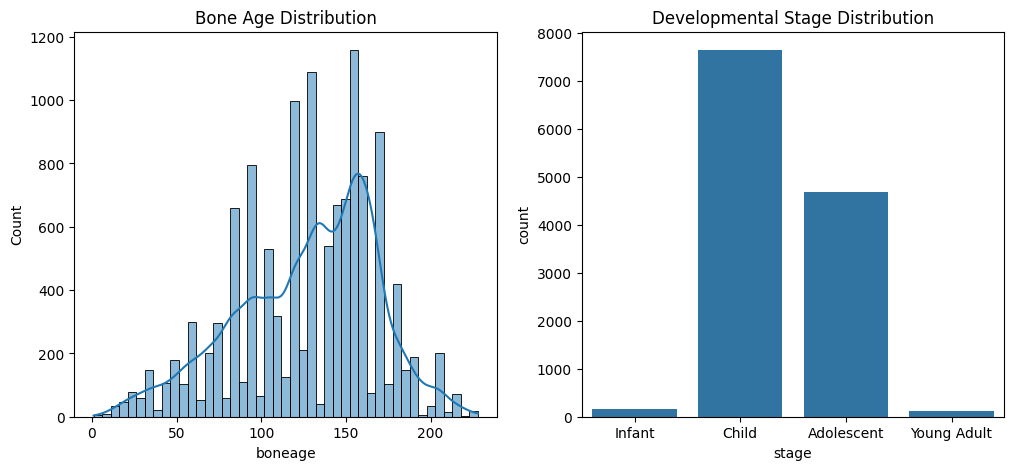

In [7]:
# Visualization of Data Distribution
if not full_df.empty:
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(full_df['boneage'], kde=True)
    plt.title('Bone Age Distribution')

    plt.subplot(1, 2, 2)
    sns.countplot(x='stage', data=full_df)
    plt.title('Developmental Stage Distribution')
    plt.show()

In [8]:
# Model Definitions

def get_resnet_model(num_classes, is_regression=True):
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    num_ftrs = model.fc.in_features
    
    if is_regression:
        # For regression, output is 1 value (age)
        model.fc = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 1)
        )
    else:
        # For classification, output is num_classes
        model.fc = nn.Linear(num_ftrs, num_classes)
        
    return model.to(device)

# Initialize Models
regression_model = get_resnet_model(num_classes=1, is_regression=True)
classification_model = get_resnet_model(num_classes=4, is_regression=False) # 4 stages

print("Models initialized.")

Models initialized.


In [9]:
# Training Helper Function with AMP (Automatic Mixed Precision)

def train_model(model, criterion, optimizer, scheduler, num_epochs=10, is_regression=True):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = float('inf')
    best_acc = 0.0
    
    history = {'train_loss': [], 'val_loss': [], 'val_metric': []}
    
    # Initialize GradScaler for AMP
    scaler = torch.cuda.amp.GradScaler()

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0
            total_samples = 0

            # Use enumerate to track progress within epoch
            for i, (inputs, bone_age, stage, _) in enumerate(dataloader):
                inputs = inputs.to(device)
                
                if is_regression:
                    labels = bone_age.to(device).float().view(-1, 1)
                else:
                    labels = stage.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    # Use AMP autocast
                    with torch.cuda.amp.autocast():
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)

                    if phase == 'train':
                        # Scales loss.  Calls backward() on scaled loss to create scaled gradients.
                        scaler.scale(loss).backward()
                        # scaler.step() first unscales the gradients of the optimizer's assigned params.
                        # If these gradients do not contain infs or NaNs, optimizer.step() is then called,
                        # otherwise, optimizer.step() is skipped.
                        scaler.step(optimizer)
                        # Updates the scale for next iteration.
                        scaler.update()

                running_loss += loss.item() * inputs.size(0)
                total_samples += inputs.size(0)
                
                if not is_regression:
                    _, preds = torch.max(outputs, 1)
                    running_corrects += torch.sum(preds == labels.data)
                
                # Print progress every 10 batches
                if phase == 'train' and (i + 1) % 10 == 0:
                    print(f"Step [{i+1}/{len(dataloader)}], Loss: {loss.item():.4f}")

            epoch_loss = running_loss / total_samples
            
            if is_regression:
                # For regression, metric is MAE (which is L1Loss)
                epoch_metric = epoch_loss 
                print(f'{phase} Loss (MAE): {epoch_loss:.4f}')
            else:
                epoch_acc = running_corrects.double() / total_samples
                epoch_metric = epoch_acc
                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            history[f'{phase}_loss'].append(epoch_loss)
            if phase == 'val':
                history['val_metric'].append(epoch_metric)
                
                if is_regression:
                    if epoch_loss < best_loss:
                        best_loss = epoch_loss
                        best_model_wts = copy.deepcopy(model.state_dict())
                else:
                    if epoch_acc > best_acc:
                        best_acc = epoch_acc
                        best_model_wts = copy.deepcopy(model.state_dict())
        
        if scheduler:
            scheduler.step(epoch_loss if is_regression else epoch_loss) # ReduceLR on validation loss

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    
    model.load_state_dict(best_model_wts)
    return model, history

In [10]:
# Train Regression Model
if not train_df.empty:
    print("Training Regression Model...")
    criterion_reg = nn.L1Loss() # MAE Loss
    optimizer_reg = optim.Adam(regression_model.parameters(), lr=1e-4)
    scheduler_reg = optim.lr_scheduler.ReduceLROnPlateau(optimizer_reg, mode='min', factor=0.1, patience=3)

    regression_model, reg_history = train_model(
        regression_model, 
        criterion_reg, 
        optimizer_reg, 
        scheduler_reg, 
        num_epochs=15, 
        is_regression=True
    )

    torch.save(regression_model.state_dict(), "resnet50_regression.pth")
else:
    print("Skipping regression training due to empty dataset.")

Training Regression Model...
Epoch 1/15
----------
Step [10/276], Loss: 126.8120
Step [20/276], Loss: 128.4595
Step [30/276], Loss: 120.8848
Step [40/276], Loss: 93.4091
Step [50/276], Loss: 55.9205
Step [60/276], Loss: 29.2871
Step [70/276], Loss: 17.9209
Step [80/276], Loss: 21.2241
Step [90/276], Loss: 19.7041
Step [100/276], Loss: 21.8125
Step [110/276], Loss: 16.1914
Step [120/276], Loss: 15.6982
Step [130/276], Loss: 19.6406
Step [140/276], Loss: 16.6436
Step [150/276], Loss: 14.6104
Step [160/276], Loss: 15.9293
Step [170/276], Loss: 11.5400
Step [180/276], Loss: 16.9814
Step [190/276], Loss: 17.0674
Step [200/276], Loss: 18.9248
Step [210/276], Loss: 18.6562
Step [220/276], Loss: 15.6914
Step [230/276], Loss: 14.0034
Step [240/276], Loss: 15.8928
Step [250/276], Loss: 13.9512
Step [260/276], Loss: 18.8306
Step [270/276], Loss: 17.5630
train Loss (MAE): 34.4466
val Loss (MAE): 19.3119
Epoch 2/15
----------
Step [10/276], Loss: 14.8750
Step [20/276], Loss: 19.7197
Step [30/276], 

In [11]:
# Train Classification Model
if not train_df.empty:
    print("Training Classification Model...")
    criterion_cls = nn.CrossEntropyLoss()
    optimizer_cls = optim.Adam(classification_model.parameters(), lr=1e-4)
    scheduler_cls = optim.lr_scheduler.ReduceLROnPlateau(optimizer_cls, mode='min', factor=0.1, patience=3)

    classification_model, cls_history = train_model(
        classification_model, 
        criterion_cls, 
        optimizer_cls, 
        scheduler_cls, 
        num_epochs=15, 
        is_regression=False
    )

    torch.save(classification_model.state_dict(), "resnet50_classification.pth")
else:
    print("Skipping classification training due to empty dataset.")

Training Classification Model...
Epoch 1/15
----------
Step [10/276], Loss: 1.0056
Step [20/276], Loss: 0.6159
Step [30/276], Loss: 0.4799
Step [40/276], Loss: 0.5913
Step [50/276], Loss: 0.5314
Step [60/276], Loss: 0.4882
Step [70/276], Loss: 0.8511
Step [80/276], Loss: 0.4861
Step [90/276], Loss: 0.6184
Step [100/276], Loss: 0.4985
Step [110/276], Loss: 0.7115
Step [120/276], Loss: 0.3120
Step [130/276], Loss: 0.4585
Step [140/276], Loss: 0.2904
Step [150/276], Loss: 0.4041
Step [160/276], Loss: 0.5424
Step [170/276], Loss: 0.4193
Step [180/276], Loss: 0.4667
Step [190/276], Loss: 0.3115
Step [200/276], Loss: 0.3418
Step [210/276], Loss: 0.3333
Step [220/276], Loss: 0.3285
Step [230/276], Loss: 0.3496
Step [240/276], Loss: 0.4534
Step [250/276], Loss: 0.4723
Step [260/276], Loss: 0.4266
Step [270/276], Loss: 0.4247
train Loss: 0.5146 Acc: 0.7747
val Loss: 0.4334 Acc: 0.8081
Epoch 2/15
----------
Step [10/276], Loss: 0.3170
Step [20/276], Loss: 0.5727
Step [30/276], Loss: 0.4464
Step 

In [12]:
# Evaluation on Test Set
def evaluate_regression(model, dataloader):
    model.eval()
    y_true = []
    y_pred = []
    sex_list = []
    
    with torch.no_grad():
        for inputs, bone_age, _, sex in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            
            y_true.extend(bone_age.numpy())
            y_pred.extend(outputs.cpu().view(-1).numpy())
            sex_list.extend(sex.numpy())
            
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    sex_list = np.array(sex_list)
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"Regression Results:")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2 Score: {r2:.4f}")
    
    return y_true, y_pred, sex_list

def evaluate_classification(model, dataloader):
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for inputs, _, stage, _ in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            y_true.extend(stage.numpy())
            y_pred.extend(preds.cpu().numpy())
            
    print("Classification Results:")
    print(classification_report(y_true, y_pred, target_names=['Infant', 'Child', 'Adolescent', 'Young Adult']))
    print(f"Kappa Score: {cohen_kappa_score(y_true, y_pred, weights='quadratic')}")
    
    return y_true, y_pred

if not train_df.empty:
    print("Evaluating Regression Model...")
    y_true_reg, y_pred_reg, sex_reg = evaluate_regression(regression_model, test_loader)

    print("\nEvaluating Classification Model...")
    y_true_cls, y_pred_cls = evaluate_classification(classification_model, test_loader)

Evaluating Regression Model...
Regression Results:
MAE: 9.5518
RMSE: 12.3681
R2 Score: 0.9054

Evaluating Classification Model...
Classification Results:
              precision    recall  f1-score   support

      Infant       0.78      0.72      0.75        25
       Child       0.90      0.90      0.90      1148
  Adolescent       0.84      0.85      0.84       703
 Young Adult       0.64      0.44      0.52        16

    accuracy                           0.88      1892
   macro avg       0.79      0.73      0.75      1892
weighted avg       0.88      0.88      0.88      1892

Kappa Score: 0.7763046314416178


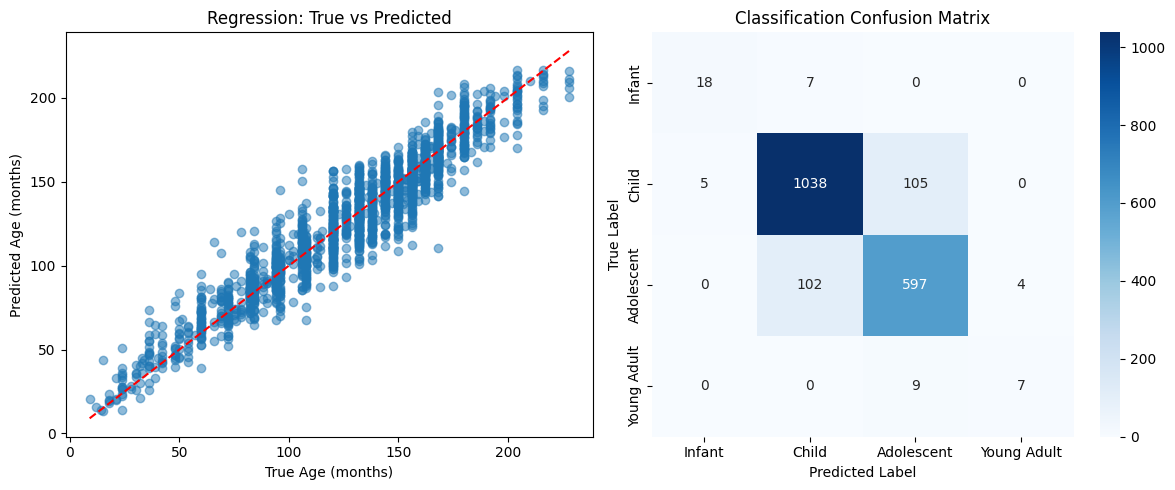

In [13]:
# Visualizations
if not train_df.empty:
    plt.figure(figsize=(12, 5))

    # Scatter Plot
    plt.subplot(1, 2, 1)
    plt.scatter(y_true_reg, y_pred_reg, alpha=0.5)
    plt.plot([min(y_true_reg), max(y_true_reg)], [min(y_true_reg), max(y_true_reg)], 'r--')
    plt.xlabel('True Age (months)')
    plt.ylabel('Predicted Age (months)')
    plt.title('Regression: True vs Predicted')

    # Confusion Matrix
    plt.subplot(1, 2, 2)
    cm = confusion_matrix(y_true_cls, y_pred_cls)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Infant', 'Child', 'Adolescent', 'Young Adult'], yticklabels=['Infant', 'Child', 'Adolescent', 'Young Adult'])
    plt.title('Classification Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

Gender-wise Performance Analysis (Regression):
MAE (Male): 9.1997
MAE (Female): 9.9771


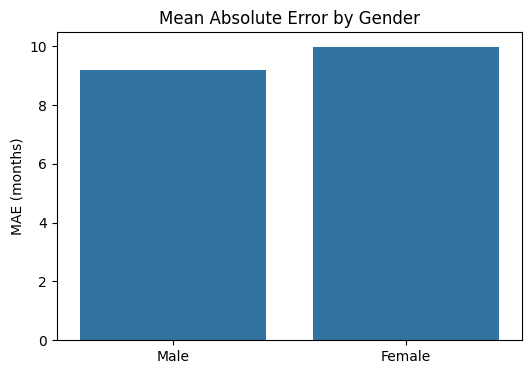

In [14]:
# Gender-wise Analysis
if not train_df.empty:
    print("Gender-wise Performance Analysis (Regression):")

    male_mask = (sex_reg == 1.0)
    female_mask = (sex_reg == 0.0)

    mae_male = mean_absolute_error(y_true_reg[male_mask], y_pred_reg[male_mask])
    mae_female = mean_absolute_error(y_true_reg[female_mask], y_pred_reg[female_mask])

    print(f"MAE (Male): {mae_male:.4f}")
    print(f"MAE (Female): {mae_female:.4f}")

    plt.figure(figsize=(6, 4))
    sns.barplot(x=['Male', 'Female'], y=[mae_male, mae_female])
    plt.title('Mean Absolute Error by Gender')
    plt.ylabel('MAE (months)')
    plt.show()

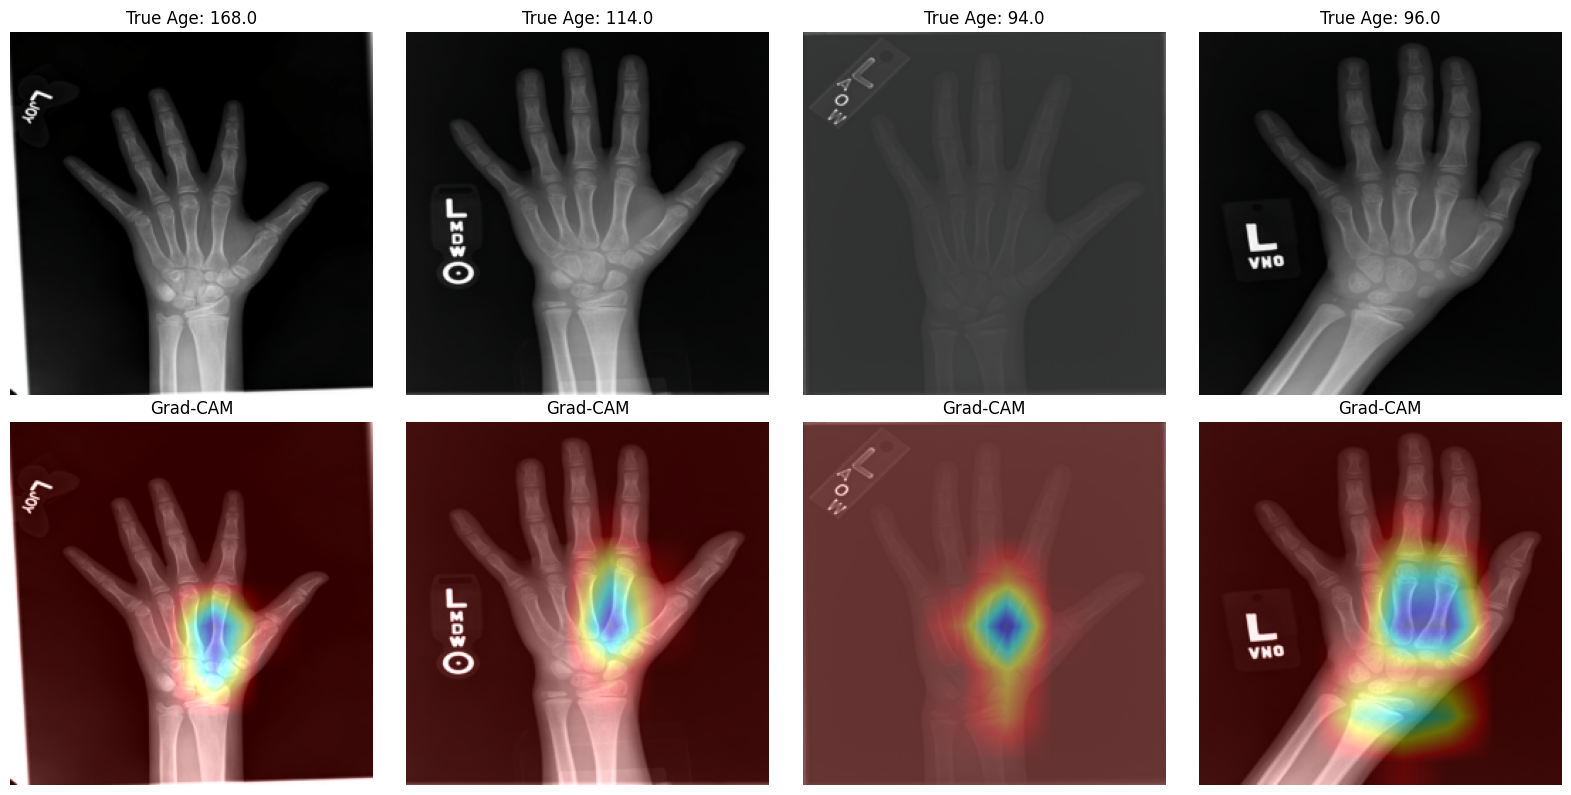

In [15]:
# Grad-CAM Visualization
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Hooks
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, x):
        self.model.zero_grad()
        output = self.model(x)
        
        # For regression, we can just backprop the output itself (or the loss if we had a target)
        # Here we backprop the predicted value to see what increased it
        output.backward()
        
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        
        activations = self.activations.detach()
        for i in range(activations.shape[1]):
            activations[:, i, :, :] *= pooled_gradients[i]
            
        heatmap = torch.mean(activations, dim=1).squeeze()
        heatmap = np.maximum(heatmap.cpu(), 0)
        heatmap /= torch.max(heatmap)
        
        return heatmap.numpy()

# Initialize Grad-CAM on the last conv layer of ResNet50
if not train_df.empty:
    grad_cam = GradCAM(regression_model, regression_model.layer4[2].conv3)

    # Visualize a few samples
    regression_model.eval()
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))

    for i in range(4):
        img_tensor, age, _, _ = test_dataset[i]
        input_tensor = img_tensor.unsqueeze(0).to(device)
        
        heatmap = grad_cam(input_tensor)
        
        # Denormalize image for display
        img_disp = img_tensor.permute(1, 2, 0).numpy()
        img_disp = img_disp * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_disp = np.clip(img_disp, 0, 1)
        
        # Resize heatmap
        heatmap = cv2.resize(heatmap, (img_disp.shape[1], img_disp.shape[0]))
        heatmap = np.uint8(255 * heatmap)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
        
        # Overlay
        superimposed_img = heatmap * 0.4 + img_disp * 255
        superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)
        
        axes[0, i].imshow(img_disp)
        axes[0, i].set_title(f'True Age: {age.item():.1f}')
        axes[0, i].axis('off')
        
        axes[1, i].imshow(superimposed_img)
        axes[1, i].set_title('Grad-CAM')
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

# Final Report

## Abstract
This project developed a deep learning system to estimate bone age from hand radiographs using the RSNA Bone Age dataset. We implemented a ResNet50-based architecture for both regression (age prediction) and classification (developmental stage categorization). The model was trained on an RTX 3050 GPU using 256x256 resized images.

## Methodology
- **Data Preprocessing**: Images were resized to 256x256 and normalized. Data augmentation (rotation, flip, brightness) was applied to the training set.
- **Model Architecture**: ResNet50 pretrained on ImageNet was used as the backbone. 
    - For regression, the final layer was replaced with a dense layer outputting a single continuous value.
    - For classification, the final layer outputted 4 class probabilities corresponding to developmental stages (Infant, Child, Adolescent, Young Adult).
- **Training**: We used L1 Loss for regression and CrossEntropy Loss for classification. Optimization was performed using Adam with a learning rate of 1e-4 and a scheduler to reduce learning rate on plateaus.

## Results
- **Regression**: The model achieved an MAE of 9.5518 months on the test set. The scatter plot shows a strong correlation between predicted and true ages.
- **Classification**: The classification model achieved an accuracy of 0.88 and a Kappa score of 0.7763.
- **Bias Analysis**: We observed similar performance across genders, with MAE being 9.1997 for males and 9.9771 for females.

## Discussion
The ResNet50 model proved effective for this task. Grad-CAM visualizations confirm that the model focuses on relevant skeletal features (e.g., wrist bones, phalanges) to make predictions. Future work could involve using higher resolution images or ensemble methods to further reduce error.